In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, log_loss, brier_score_loss

In [16]:
df = pd.read_csv('../data/predictions_older.csv')
df

,event_date,event_name,fighter_red,fighter_blue,weight_class,predicted_winner,confidence,winner
0,2026-02-07,UFC Fight Night: Bautista vs. Oliveira,Alex Morono,Daniil Donchenko,Welterweight,Daniil Donchenko,0.853,Daniil Donchenko
1,2026-02-07,UFC Fight Night: Bautista vs. Oliveira,Klaudia Sygula,Priscila Cachoeira,Women's Bantamweight,Klaudia Sygula,0.907,Klaudia Sygula
2,2026-02-07,UFC Fight Night: Bautista vs. Oliveira,Nikolay Veretennikov,Niko Price,Welterweight,Nikolay Veretennikov,0.586,Nikolay Veretennikov
3,2026-02-07,UFC Fight Night: Bautista vs. Oliveira,Amir Albazi,Kyoji Horiguchi,Flyweight,Kyoji Horiguchi,0.835,Kyoji Horiguchi
4,2026-02-07,UFC Fight Night: Bautista vs. Oliveira,Mario Bautista,Vinicius Oliveira,Bantamweight,Vinicius Oliveira,0.633,Mario Bautista
5,2026-02-07,UFC Fight Night: Bautista vs. Oliveira,Jailton Almeida,Rizvan Kuniev,Heavyweight,Rizvan Kuniev,0.662,Rizvan Kuniev
6,2026-02-07,UFC Fight Night: Bautista vs. Oliveira,Michal Oleksiejczuk,Marc-Andre Barriault,Middleweight,Michal Oleksiejczuk,0.575,Michal Oleksiejczuk
7,2026-01-31,UFC 325: Volkanovski vs. Lopes 2,Sulangrangbo,Lawrence Lui,Road to UFC 4 Bantamweight Tournament Title,Sulangrangbo,0.510,Lawrence Lui
8,2026-01-31,UFC 325: Volkanovski vs. Lopes 2,Junior Tafa,Billy Elekana,Light Heavyweight,Billy Elekana,0.622,Billy Elekana
9,2026-01-31,UFC 325: Volkanovski vs. Lopes 2,Cam Rowston,Cody Brundage,Middleweight,Cam Rowston,0.868,Cam Rowston


In [17]:
def evaluate_confidence(df, n_bins=10):
    # 1. Setup Ground Truth
    df['is_correct'] = (df['predicted_winner'] == df['winner']).astype(int)
    
    # Calculate Global Stats for the Title
    avg_conf = df['confidence'].mean()
    avg_acc = df['is_correct'].mean()

    # 2. Threshold Calculations
    thresholds = np.linspace(0.5, 0.95, 50)
    thresh_results = []
    for t in thresholds:
        subset = df[df['confidence'] >= t]
        acc = subset['is_correct'].mean() if len(subset) > 0 else 0
        coverage = len(subset) / len(df)
        thresh_results.append({'threshold': t, 'accuracy': acc, 'coverage': coverage})
    
    thresh_df = pd.DataFrame(thresh_results)
    
    # 3. Plotting
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # --- Plot A: Dynamic Accuracy/Coverage ---
    ax1.plot(thresh_df['threshold'], thresh_df['accuracy'], color='red', lw=2, label='Accuracy')
    ax1_twin = ax1.twinx()
    ax1_twin.fill_between(thresh_df['threshold'], thresh_df['coverage'], alpha=0.1, color='blue')
    
    ax1.set_title(f'Performance vs. Selectivity\n(Global Accuracy: {avg_acc:.1%})')
    ax1.set_xlabel('Confidence Threshold')
    ax1.set_ylabel('Accuracy')
    ax1_twin.set_ylabel('Coverage (% of Fights Kept)')
    ax1.grid(True, alpha=0.3)

    # --- Plot B: Dynamic Reliability Diagram ---
    bins = np.linspace(0.5, 1.0, n_bins + 1)
    df['bin'] = pd.cut(df['confidence'], bins=bins)
    binned = df.groupby('bin', observed=False).agg({'is_correct': 'mean', 'confidence': 'mean'})
    
    ax2.bar(binned['confidence'], binned['is_correct'], width=0.03, alpha=0.7, color='gray', label='Actual')
    ax2.plot([0.5, 1.0], [0.5, 1.0], '--', color='red', label='Perfect Calibration')
    
    # Dynamic Title based on your data
    ax2.set_title(f'Reliability: {avg_conf:.1%} Avg Conf vs. {avg_acc:.1%} Avg Acc')
    ax2.set_xlabel('Model Confidence Score')
    ax2.set_ylabel('Actual Win Rate')
    ax2.legend()

    plt.tight_layout()
    plt.show()

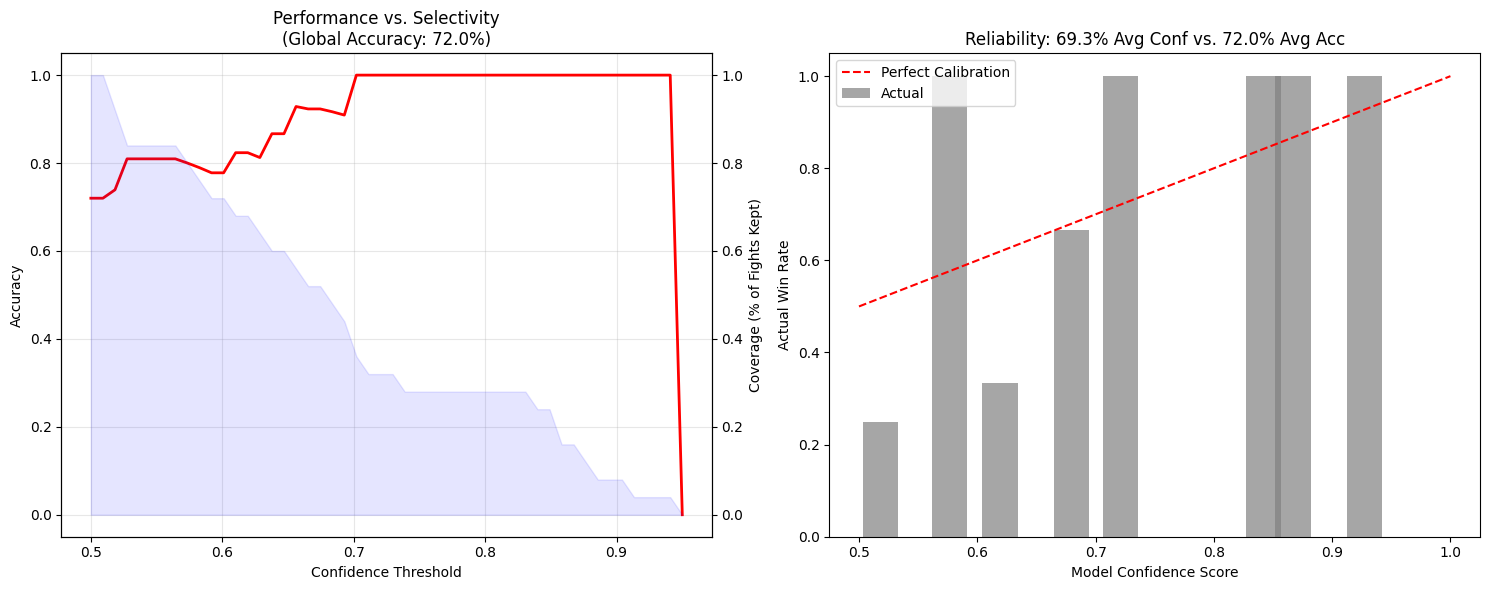

In [18]:
evaluate_confidence(df)

In [19]:
def advanced_evaluation(df):
    # 1. Basic Stats
    y_true = (df['winner'] == df['fighter_red']).astype(int) # 1 for Red, 0 for Blue
    y_pred = (df['predicted_winner'] == df['fighter_red']).astype(int)
    y_prob = df['confidence'] # Assuming confidence is probability for the predicted winner
    
    # Note: For Log Loss, you need the probability of the RED fighter specifically.
    # If confidence is just "winner's prob", we adjust:
    red_probs = np.where(df['predicted_winner'] == df['fighter_red'], y_prob, 1 - y_prob)

    # 2. Calculate Metrics
    loss = log_loss(y_true, red_probs)
    brier = brier_score_loss(y_true, red_probs)
    cm = confusion_matrix(y_true, y_pred)

    print(f"--- Advanced Metrics ---")
    print(f"Log Loss: {loss:.4f} (Lower is better)")
    print(f"Brier Score: {brier:.4f} (Below 0.25 is good)")
    
    # 3. Plot Confusion Matrix
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Blue Wins', 'Red Wins'], 
                yticklabels=['Blue Wins', 'Red Wins'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix: Red vs. Blue Bias')
    plt.show()

--- Advanced Metrics ---
Log Loss: 0.4903 (Lower is better)
Brier Score: 0.1628 (Below 0.25 is good)


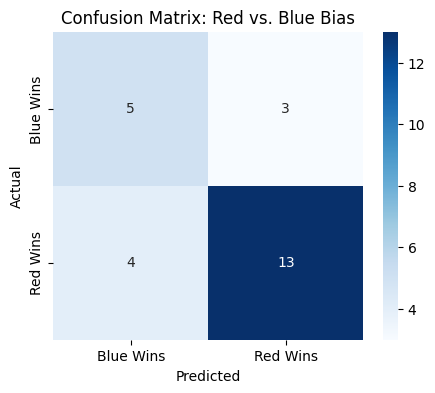

In [20]:
advanced_evaluation(df)